In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [5]:
df = pd.read_csv("Unemployment in India.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [12]:
# remove extra spaces in column names
df.columns = df.columns.str.strip()

# convert date column
df['Date'] = pd.to_datetime(df['Date'])

df.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate'
}, inplace=True)

df.head()

,Region,Date,Frequency,Unemployment_Rate,Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


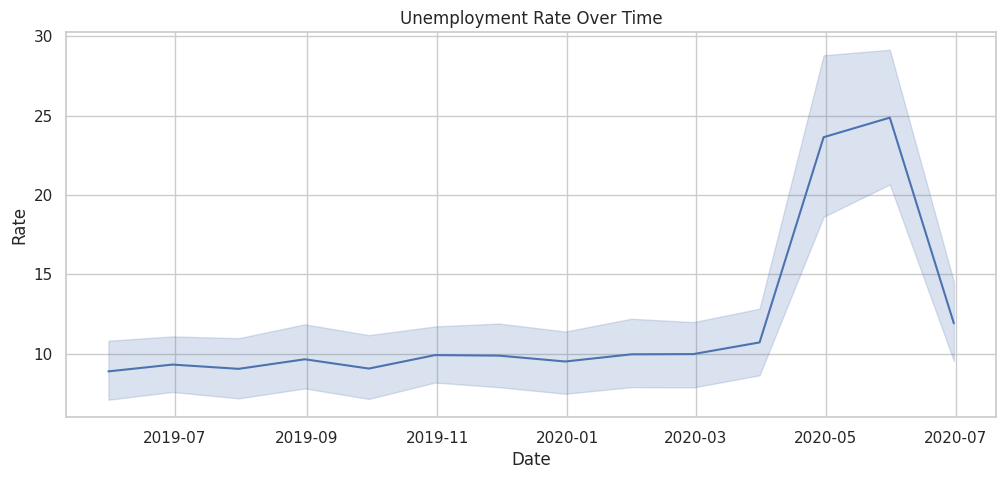

In [10]:
plt.figure(figsize=(12,5))
sns.lineplot(x='Date', y='Unemployment_Rate', data=df)
plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Rate")
plt.show()

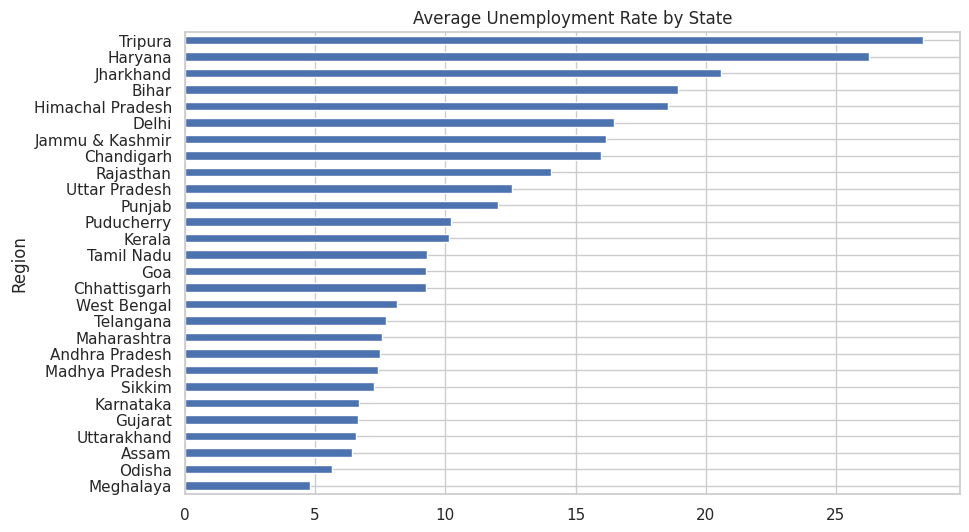

In [13]:
state_avg = df.groupby('Region')['Unemployment_Rate'].mean().sort_values()

plt.figure(figsize=(10,6))
state_avg.plot(kind='barh')
plt.title("Average Unemployment Rate by State")
plt.show()

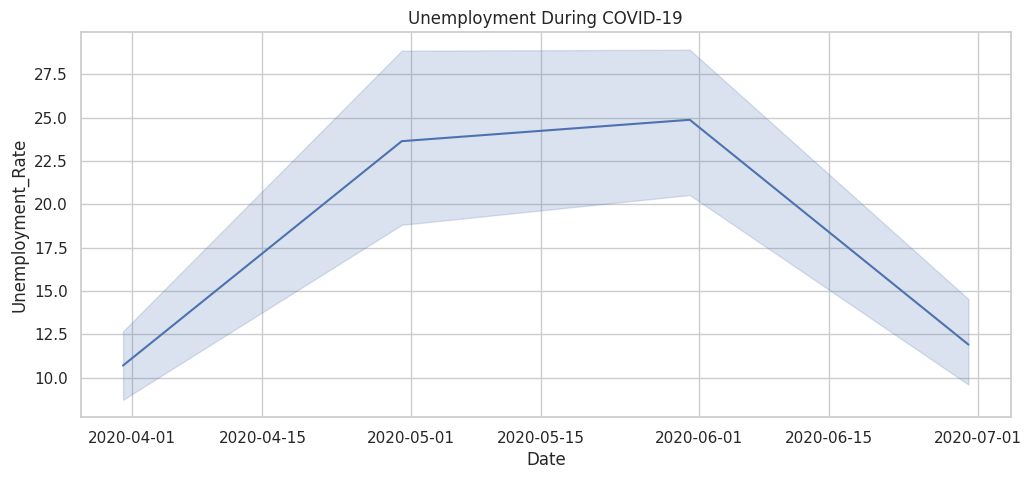

In [14]:
covid_data = df[df['Date'] >= '2020-03-01']

plt.figure(figsize=(12,5))
sns.lineplot(x='Date', y='Unemployment_Rate', data=covid_data)
plt.title("Unemployment During COVID-19")
plt.show()

In [20]:
from sklearn.linear_model import LinearRegression

# Fix Date column
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Drop invalid dates
df = df.dropna(subset=['Date'])

# Convert to ordinal
df['Date_Ordinal'] = df['Date'].apply(lambda x: x.toordinal())

X = df[['Date_Ordinal']]
y = df['Unemployment_Rate']

model = LinearRegression()
model.fit(X, y)

LinearRegression()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


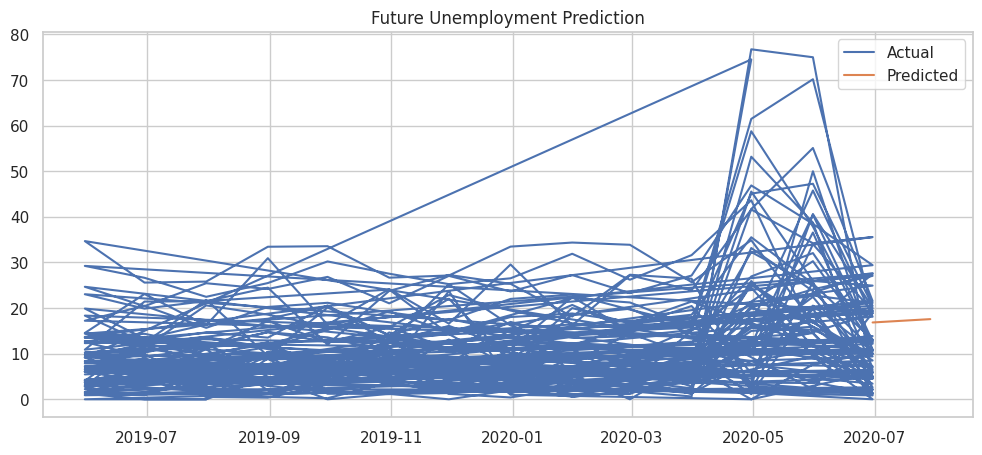

In [21]:
# future dates
future_dates = pd.date_range(start=df['Date'].max(), periods=30)

future_ordinal = future_dates.map(pd.Timestamp.toordinal).values.reshape(-1,1)

predictions = model.predict(future_ordinal)

# plot
plt.figure(figsize=(12,5))
plt.plot(df['Date'], y, label='Actual')
plt.plot(future_dates, predictions, label='Predicted')
plt.legend()
plt.title("Future Unemployment Prediction")
plt.show()